# Sprint 2 Notebook
## To Do
- Recreate PCA & Clustering from Sprint 1 **DONE**
- Develop methodology for scoring system **DONE**
- Run on all quarters

In [21]:
!ls '/project_data/data_asset'
# these are the data files that are available to us
# they can be loaded into this notebook by using the `0100` button in the top right corner

2019q1_clusteredrisk.csv	   op_analysis_01012019_03312019.csv
2019q1_riskscore.csv		   op_analysis_01012020_03312020.csv
2019q2_clusteredrisk.csv	   op_analysis_04012018_06302018.csv
2019q2_riskscore.csv		   op_analysis_04012019_06302019.csv
2019q3_clusteredrisk.csv	   op_analysis_07012018_09302018.csv
2019q3_riskscore.csv		   op_analysis_07012019_09302019.csv
2019q4_clusteredrisk.csv	   op_analysis_10012018_12312018.csv
2019q4_riskscore.csv		   op_analysis_10012019_12312019.csv
2020q1_clusteredrisk.csv	   op_analysis.csv
2020q1_riskscore.csv		   op_analysis_with_nulls.csv
2020q2_clusteredrisk.csv	   op_analysis_with_nulls_with_labels.csv
2020q2_riskscore.csv		   provider-of-interest-export.csv
arcgis_creds_alex.json		   revised_op_analysis_01012018_03312018.csv
colorado-latest.osm.bz2		   revised_op_analysis_01012019_03312019.csv
connect_oracle_db.R		   revised_op_analysis_01012020_03312020.csv
creds.json			   revised_op_analysis_04012019_06302019.csv
joined_df.csv			   revised_op_ana

In [1]:
# import some libraries into the notebook
# all these libraries are pre-installed in Cloud Pak for Data (dont need to download), so all we have to do is import

import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
import sys
from scipy import stats

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.pyplot import figure
%matplotlib inline

## 0.0 Preprocessing and Functions

In [2]:
# define a preprocessor
# handle scaling and imputation

# inputs: binary columns and continuous columns (even if bounded by [0,1])

def preprocessor_sprint2_refine(binary_feats, num_feats):
    '''
    binary_feats is a python list of the features that are binary
    num_features is a python list of numerical features
    '''
    

#     fill_with_mean = ['Member Count', 'Count Script', 'Sum Dispensed Quantity', 'Total Days', 'PR1', 'PR2', 'PR3', 'PR4']
#     fill_with_zero = [c for c in features if c not in fill_with_mean]
    
    
    scaler = StandardScaler()
    
    numerical_pipeline = make_column_transformer((make_pipeline(SimpleImputer(strategy='constant', fill_value=0)), binary_feats),
                                                 (make_pipeline(SimpleImputer(strategy='constant', fill_value=0), scaler), num_feats),
                                                 remainder='drop')
    
    preprocessor = make_column_transformer((numerical_pipeline, features), 
                                           remainder='drop')
    
    feature_names_reordered = binary_feats+num_feats
    
    return preprocessor, feature_names_reordered

In [3]:
# write function to make the scoring repeatable
# instead of taking a df, lets make this function take a scikit learn object

def scoring_sum(df):
    
    df1 = pd.DataFrame()
    
    df1['Sum'] = df.sum(axis=1)
    
    mm_scaler = MinMaxScaler(feature_range=(0,100))
    df1['Score'] = mm_scaler.fit_transform(df1[['Sum']])
    df1['Bin'] = pd.cut(df1['Score'], [0,10,20,50,100])

    
    return df1[['Sum', 'Score', 'Bin']]

## 1.0 Scoring for Q1 2019

In [4]:
# read in 1 quarter of data to start the scoring
# the '/project_data/data_asset' folder contains the quarterly data

df_q1_2019 = pd.read_csv('/project_data/data_asset/op_analysis_01012019_03312019.csv')
display(df_q1_2019.head())
print(df_q1_2019.shape)

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,25,55,4270.0,2019-03-26,2019-01-02,114867,84,2.2,170.800000,0.654762,50.833333,0.075342,0.04,2,0.0,0.0,0.024390,0.418182,0.790875,0,0,0.0,0.000000,5,0.7,0.0,0.080000,0.0,0.0,0.000000,0,0.0
1,18,18,175.0,2019-03-25,2019-01-13,102896,72,1.0,9.722222,0.250000,2.430556,0.108108,0.00,0,0.0,0.0,0.000000,0.777778,0.783133,0,0,0.0,0.055556,0,0.0,0.0,0.111111,0.0,0.0,0.333333,0,0.0
2,5,15,710.0,2019-03-25,2019-01-02,104658,83,3.0,142.000000,0.180723,8.554217,0.102041,0.00,1,0.0,0.0,0.018868,0.133333,0.897959,0,0,0.0,0.200000,0,0.0,0.0,0.200000,0.0,0.0,0.000000,0,0.2
3,1,1,28.0,2019-01-11,2019-01-11,122110,1,1.0,28.000000,1.000000,28.000000,0.500000,1.00,0,0.0,0.0,0.000000,0.000000,0.857143,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0
4,5,20,733.0,2019-03-20,2019-01-01,122574,79,4.0,146.600000,0.253165,9.278481,0.034783,0.00,1,0.0,0.0,0.050000,0.150000,0.642857,0,0,0.0,0.200000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0


(13451, 32)


## 1.1 Ensure data quality

In [6]:
# see is there are any missing values
# should be no missing values because they were filled when we pulled from db
df_q1_2019.isna().mean()

Member Count              0.0
Count Script              0.0
Sum Dispensed Quantity    0.0
Max Dispense Date         0.0
Min Dispense Date         0.0
PRSCRB_PROV_LOC_ID        0.0
Total Days                0.0
PR2                       0.0
PR1                       0.0
PR4                       0.0
PR3                       0.0
PR5                       0.0
PR6                       0.0
PR7                       0.0
PR8                       0.0
PR9                       0.0
PR10                      0.0
PR11                      0.0
PR13                      0.0
PR15                      0.0
PR18                      0.0
PR19                      0.0
PR21                      0.0
PR22                      0.0
PR23                      0.0
PR24                      0.0
PR25                      0.0
PR26                      0.0
PR27                      0.0
PR28                      0.0
PR29                      0.0
PR30                      0.0
dtype: float64

In [49]:

df_q1_2019['PR29'].value_counts(dropna=False)

0    13451
Name: PR29, dtype: int64

- PR 15 and PR 29 are either all Null, all 0, or a mix
- We will treat it as all 0

In [11]:
for col in df_preprocessed_numerical:
    print(col, df_preprocessed_numerical[col].mean())

Member Count -8.738497662858864e-16
Count Script -1.6331858589144282e-16
Sum Dispensed Quantity 2.9649004816796196e-16
Total Days -9.91318312018287e-16
PR2 -6.955917433669249e-17
PR1 1.9116041405786596e-15
PR4 9.970629795161617e-18
PR3 -1.2745568319278617e-16
PR5 0.1549446183236493
PR6 0.04330701405460678
PR7 0.3861422942532154
PR8 8.780974465518693e-05
PR9 0.0005620195946325287
PR10 0.013595605991354846
PR11 0.3955049578183328
PR13 0.792453202547358
PR15 0.0
PR18 0.0008177830644561742
PR19 0.0011915914117235807
PR21 0.022231019362167696
PR22 1.809382202066761
PR23 0.03374898796369106
PR24 0.0013693232064290334
PR25 0.048936968583531526
PR26 0.0019228422891112457
PR27 1.3744396472848644e-05
PR28 0.21366379794428303
PR29 0.0
PR30 0.003622994460939554


In [47]:
# PR 15 and 18 are binary
# double check
print('PR15\n', df_q1_2019['PR15'].value_counts(dropna=False))
print('PR18\n', df_q1_2019['PR18'].value_counts(dropna=False))

PR15
 0    13451
Name: PR15, dtype: int64
PR18
 0    13440
1       11
Name: PR18, dtype: int64


In [12]:
print('number of unique provider ids: ',df_q1_2019['PRSCRB_PROV_LOC_ID'].nunique())
print('number of rows: ',df_q1_2019.shape[0])

number of unique provider ids:  13451
number of rows:  13451


### 1.1 Make lists for preprocessor

In [7]:
# define list of columns before preprocessing
to_drop = []
index = ['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date']
binary_features = ['PR18']
features = [c for c in df_q1_2019 if c not in index+to_drop+binary_features]
num_features = df_q1_2019[features].select_dtypes('number').columns.tolist()

In [17]:
# call preprocessing function
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

### 1.2 Apply preprocessor for Q1 2019, Sum PR's

In [128]:
# view transformed data to ensure we did this right

transformed_tmp = preprocessor_refine.transformers[0][1].fit_transform(df_q1_2019[binary_features+num_features])
df_refined = pd.DataFrame(data=transformed_tmp, columns=features_names, index=df_q1_2019.index)
df_intermediate = pd.concat([df_q1_2019[index], df_refined], axis=1)
df_for_scoring = df_intermediate.set_index(['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date'])
df_for_scoring['Sum'] = df_for_scoring.sum(axis=1)
df_for_scoring.head()

,,,PR18,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Sum
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
114867,2019-03-26,2019-01-02,0.0,0.890816,0.701075,0.956598,0.962812,0.612454,1.179371,0.311768,0.774344,-0.381607,-0.019922,0.812395,-0.062877,-0.035368,0.185834,0.059823,-0.008090,0.0,-0.065166,-0.252296,0.273102,4.249860,-0.059603,0.225168,-0.076997,-0.017072,-0.758930,0.0,-0.108941,10.348550
102896,2019-03-25,2019-01-13,0.0,0.485147,-0.032763,-0.236687,0.589334,-0.710057,-0.731951,-0.320375,-0.372406,-0.224531,-0.260885,-0.194379,-0.062877,-0.035368,-0.234054,1.008454,-0.047766,0.0,-0.065166,0.378194,-0.154875,-0.215277,-0.059603,0.450685,-0.076997,-0.017072,0.425064,0.0,-0.108941,-0.825153
104658,2019-03-25,2019-01-02,0.0,-0.268239,-0.092264,-0.080788,0.931689,1.494129,0.837635,-0.428569,-0.227326,-0.253617,-0.260885,0.309008,-0.062877,-0.035368,0.090765,-0.691621,0.540694,0.0,-0.065166,2.017468,-0.154875,-0.215277,-0.059603,1.095018,-0.076997,-0.017072,-0.758930,0.0,5.904924,9.471856
122110,2019-01-11,2019-01-11,0.0,-0.500049,-0.369933,-0.279523,-1.620411,-0.710057,-0.515070,0.850949,0.233380,1.654171,5.763204,-0.194379,-0.062877,-0.035368,-0.234054,-1.043361,0.331520,0.0,-0.065166,-0.252296,-0.154875,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,-0.758930,0.0,-0.108941,1.204254
122574,2019-03-20,2019-01-01,0.0,-0.268239,0.006904,-0.074085,0.807196,2.596221,0.892218,-0.315432,-0.210166,-0.576048,-0.260885,0.309008,-0.062877,-0.035368,0.626717,-0.647654,-0.766646,0.0,-0.065166,2.017468,-0.154875,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,-0.758930,0.0,-0.108941,2.226739


### 1.3 Define Scaler
- We use MinMax Scaling with range [0,100] 

In [ ]:
# define MinMax Scaler that we will use
mm_scaler = MinMaxScaler(feature_range=(0,100))


In [82]:
# transform the data to be on the 0-100 scale

scoring_scaled_int = mm_scaler.fit_transform(df_for_scoring[['Sum']])
scoring_scaled = pd.DataFrame(data=scoring_scaled_int, columns=['Score'], index=df_for_scoring.index)
scoring_scaled.head()

,,,Score
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,
114867,2019-03-26,2019-01-02,10.186527
102896,2019-03-25,2019-01-13,5.214015
104658,2019-03-25,2019-01-02,9.796381
122110,2019-01-11,2019-01-11,6.117140
122574,2019-03-20,2019-01-01,6.572165


In [83]:
# we can see some overall view of the scores
scoring_scaled.describe()

,Score
count,13451.000000
mean,5.581588
std,3.857914
min,0.000000
25%,3.693944
50%,4.782270
75%,6.316909
max,100.000000


### 1.5 Make bins for groups of risky actors

In [84]:
scoring_scaled['Bin'] = pd.cut(scoring_scaled['Score'], [0,10,20,50,100])
scoring_scaled.head()

,,,Score,Bin
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,,
114867,2019-03-26,2019-01-02,10.186527,"(10, 20]"
102896,2019-03-25,2019-01-13,5.214015,"(0, 10]"
104658,2019-03-25,2019-01-02,9.796381,"(0, 10]"
122110,2019-01-11,2019-01-11,6.117140,"(0, 10]"
122574,2019-03-20,2019-01-01,6.572165,"(0, 10]"


In [85]:
# there are only 11 prescribers who have a risk score about 50
# these bins can be changed
scoring_scaled.groupby(['Bin']).size()

Bin
(0, 10]      12566
(10, 20]       731
(20, 50]       138
(50, 100]       11
dtype: int64

In [92]:
q1_highrisk = scoring_scaled.loc[scoring_scaled['Score'] >= 50].reset_index()['PRSCRB_PROV_LOC_ID'].tolist()
q1_highrisk

[122949,
 165027,
 107410,
 156800,
 152853,
 154518,
 139433,
 16638,
 17522,
 153504,
 165594]

## 1.5 Use only functions

In [8]:
# call preprocessing function
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)
transformed_tmp = preprocessor_refine.transformers[0][1].fit_transform(df_q1_2019[binary_features+num_features])
df_refined = pd.DataFrame(data=transformed_tmp, columns=features_names, index=df_q1_2019.index)
df_intermediate = pd.concat([df_q1_2019[index], df_refined], axis=1)
df_for_scoring = df_intermediate.set_index(['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date'])
df_for_scoring.head()

,,,PR18,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
114867,2019-03-26,2019-01-02,0.0,0.890816,0.701075,0.956598,0.962812,0.612454,1.179371,0.311768,0.774344,-0.381607,-0.019922,0.812395,-0.062877,-0.035368,0.185834,0.059823,-0.008090,0.0,-0.065166,-0.252296,0.273102,4.249860,-0.059603,0.225168,-0.076997,-0.017072,-0.758930,0.0,-0.108941
102896,2019-03-25,2019-01-13,0.0,0.485147,-0.032763,-0.236687,0.589334,-0.710057,-0.731951,-0.320375,-0.372406,-0.224531,-0.260885,-0.194379,-0.062877,-0.035368,-0.234054,1.008454,-0.047766,0.0,-0.065166,0.378194,-0.154875,-0.215277,-0.059603,0.450685,-0.076997,-0.017072,0.425064,0.0,-0.108941
104658,2019-03-25,2019-01-02,0.0,-0.268239,-0.092264,-0.080788,0.931689,1.494129,0.837635,-0.428569,-0.227326,-0.253617,-0.260885,0.309008,-0.062877,-0.035368,0.090765,-0.691621,0.540694,0.0,-0.065166,2.017468,-0.154875,-0.215277,-0.059603,1.095018,-0.076997,-0.017072,-0.758930,0.0,5.904924
122110,2019-01-11,2019-01-11,0.0,-0.500049,-0.369933,-0.279523,-1.620411,-0.710057,-0.515070,0.850949,0.233380,1.654171,5.763204,-0.194379,-0.062877,-0.035368,-0.234054,-1.043361,0.331520,0.0,-0.065166,-0.252296,-0.154875,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,-0.758930,0.0,-0.108941
122574,2019-03-20,2019-01-01,0.0,-0.268239,0.006904,-0.074085,0.807196,2.596221,0.892218,-0.315432,-0.210166,-0.576048,-0.260885,0.309008,-0.062877,-0.035368,0.626717,-0.647654,-0.766646,0.0,-0.065166,2.017468,-0.154875,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,-0.758930,0.0,-0.108941


In [13]:
df_q1_final = scoring_sum(df_for_scoring)
df_q1_final.head()

,,,Sum,Score,Bin
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,,,
114867,2019-03-26,2019-01-02,10.348550,10.186527,"(10, 20]"
102896,2019-03-25,2019-01-13,-0.825153,5.214015,"(0, 10]"
104658,2019-03-25,2019-01-02,9.471856,9.796381,"(0, 10]"
122110,2019-01-11,2019-01-11,1.204254,6.117140,"(0, 10]"
122574,2019-03-20,2019-01-01,2.226739,6.572165,"(0, 10]"


In [14]:
df_q1_final.groupby(['Bin']).size()

Bin
(0, 10]      12566
(10, 20]       731
(20, 50]       138
(50, 100]       11
dtype: int64

In [15]:
df_q1_final['Score'].describe()

count    13451.000000
mean         5.581588
std          3.857914
min          0.000000
25%          3.693944
50%          4.782270
75%          6.316909
max        100.000000
Name: Score, dtype: float64

## TODO
- apply this to other quarters
- check if providers are in the same bins across different quarters

## 2.0 Apply to Q2 2019

In [52]:
df_q2_2019 = pd.read_csv('/project_data/data_asset/op_analysis_04012019_06302019.csv')
df_q2_2019.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,211,544,42956.0,2019-06-29,2019-04-01,164940,90,2.578199,203.582938,6.044444,477.288889,0.492521,0.018957,35,0.00000,0.0,0.021186,0.845588,0.581860,0,0,0.004739,0.061611,99,0.0,0.0,0.260664,0.0,0.0,0.232227,0,0.004739
1,58,100,8468.0,2019-06-30,2019-04-01,149543,91,1.724138,146.000000,1.098901,93.054945,0.049180,0.034483,1,0.00053,0.0,0.013453,0.420000,0.879952,0,0,0.000000,0.086207,4,0.0,0.0,0.068966,0.0,0.0,0.310345,0,0.000000
2,25,71,4256.0,2019-06-27,2019-04-01,121521,88,2.840000,170.240000,0.806818,48.363636,0.068404,0.000000,1,0.00000,0.0,0.028986,0.211268,0.785498,0,0,0.000000,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.120000,0,0.000000
3,37,100,4516.0,2019-06-30,2019-04-01,101625,91,2.702703,122.054054,1.098901,49.626374,0.120000,0.027027,2,0.00000,0.0,0.023810,0.120000,0.744246,0,0,0.000000,0.027027,1,0.0,0.0,0.000000,0.0,0.0,0.108108,0,0.000000
4,2,2,60.0,2019-04-25,2019-04-24,107033,2,1.000000,30.000000,1.000000,30.000000,0.500000,0.000000,0,0.00000,0.0,0.000000,0.000000,0.666667,0,0,0.000000,0.000000,2,0.0,0.0,0.000000,0.0,0.0,0.500000,0,0.000000


In [53]:
# define list of columns before preprocessing
# to_drop = []
# index = ['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date']
# binary_features = ['PR18']
features_q2 = [c for c in df_q2_2019 if c not in index+to_drop+binary_features]
num_features_q2 = df_q2_2019[features_q2].select_dtypes('number').columns.tolist()

In [64]:
# view transformed data to ensure we did this right

transformed_tmp_q2 = preprocessor_refine.transformers[0][1].fit_transform(df_q2_2019[binary_features+num_features])
df_refined_q2 = pd.DataFrame(data=transformed_tmp_q2, columns=features_names, index=df_q2_2019.index)
df_refined_q2 = pd.concat([df_q2_2019[index], df_refined_q2], axis=1)
df_refined_q2.head()

,PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,PR18,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,164940,2019-06-29,2019-04-01,0.0,12.521518,11.020684,12.532519,1.102125,1.012539,1.541467,9.230215,11.253943,1.608837,-0.155306,16.851566,-0.116609,-0.038766,0.141395,1.180879,-1.062389,0.0,0.332410,0.451126,8.527237,-0.22311,-0.0764,1.529786,-0.054871,-0.014417,0.056805,0.0,0.025034
1,149543,2019-06-30,2019-04-01,0.0,3.026808,1.706352,2.243489,1.132481,0.088913,0.870887,1.084375,1.851398,-0.511494,-0.063525,0.301777,0.692352,-0.038766,0.013212,0.066782,0.449100,0.0,-0.046334,0.728740,0.201233,-0.22311,-0.0764,0.140987,-0.054871,-0.014417,0.332081,0.0,-0.109272
2,121521,2019-06-27,2019-04-01,0.0,0.978930,1.097984,0.986895,1.041414,1.295664,1.153173,0.603283,0.757762,-0.419555,-0.267375,0.301777,-0.116609,-0.038766,0.270664,-0.479633,-0.029831,0.0,-0.046334,-0.244292,-0.149335,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,-0.338671,0.0,-0.109272
3,101625,2019-06-30,2019-04-01,0.0,1.723613,1.706352,1.064462,1.132481,1.147183,0.592026,1.084375,0.788662,-0.172790,-0.107601,0.788535,-0.116609,-0.038766,0.184872,-0.718552,-0.239006,0.0,-0.046334,0.060767,-0.061693,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,-0.380576,0.0,-0.109272
4,107033,2019-04-25,2019-04-24,0.0,-0.448380,-0.349514,-0.264925,-1.569166,-0.694208,-0.479986,0.921474,0.308387,1.644604,-0.267375,-0.184982,-0.116609,-0.038766,-0.209769,-1.032686,-0.632374,0.0,-0.046334,-0.244292,0.025949,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,1.000403,0.0,-0.109272


In [65]:
df_for_scoring_q2 = df_refined_q2.set_index(index)
df_for_scoring_q2['Sum'] = df_for_scoring_q2.sum(axis=1)
df_for_scoring_q2.head()

,,,PR18,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Sum
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
164940,2019-06-29,2019-04-01,0.0,12.521518,11.020684,12.532519,1.102125,1.012539,1.541467,9.230215,11.253943,1.608837,-0.155306,16.851566,-0.116609,-0.038766,0.141395,1.180879,-1.062389,0.0,0.332410,0.451126,8.527237,-0.22311,-0.0764,1.529786,-0.054871,-0.014417,0.056805,0.0,0.025034,89.178217
149543,2019-06-30,2019-04-01,0.0,3.026808,1.706352,2.243489,1.132481,0.088913,0.870887,1.084375,1.851398,-0.511494,-0.063525,0.301777,0.692352,-0.038766,0.013212,0.066782,0.449100,0.0,-0.046334,0.728740,0.201233,-0.22311,-0.0764,0.140987,-0.054871,-0.014417,0.332081,0.0,-0.109272,13.792777
121521,2019-06-27,2019-04-01,0.0,0.978930,1.097984,0.986895,1.041414,1.295664,1.153173,0.603283,0.757762,-0.419555,-0.267375,0.301777,-0.116609,-0.038766,0.270664,-0.479633,-0.029831,0.0,-0.046334,-0.244292,-0.149335,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,-0.338671,0.0,-0.109272,5.520424
101625,2019-06-30,2019-04-01,0.0,1.723613,1.706352,1.064462,1.132481,1.147183,0.592026,1.084375,0.788662,-0.172790,-0.107601,0.788535,-0.116609,-0.038766,0.184872,-0.718552,-0.239006,0.0,-0.046334,0.060767,-0.061693,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,-0.380576,0.0,-0.109272,7.554681
107033,2019-04-25,2019-04-24,0.0,-0.448380,-0.349514,-0.264925,-1.569166,-0.694208,-0.479986,0.921474,0.308387,1.644604,-0.267375,-0.184982,-0.116609,-0.038766,-0.209769,-1.032686,-0.632374,0.0,-0.046334,-0.244292,0.025949,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,1.000403,0.0,-0.109272,-3.515266


In [78]:
# transform the data to be on the 0-100 scale

scoring_scaled_int_q2 = mm_scaler.fit_transform(df_for_scoring_q2[['Sum']])
scoring_scaled_q2 = pd.DataFrame(data=scoring_scaled_int_q2, columns=['Score'], index=df_for_scoring_q2.index)
scoring_scaled_q2.head()

,,,Score
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,
164940,2019-06-29,2019-04-01,43.811849
149543,2019-06-30,2019-04-01,11.500122
121521,2019-06-27,2019-04-01,7.954424
101625,2019-06-30,2019-04-01,8.826348
107033,2019-04-25,2019-04-24,4.081544


In [68]:
# we can see some overall view of the scores
scoring_scaled_q2.describe()

,Score
count,13449.000000
mean,5.588546
std,3.747114
min,0.000000
25%,3.783473
50%,4.827550
75%,6.254594
max,100.000000


In [93]:
scoring_scaled_q2['Bin'] = pd.cut(scoring_scaled_q2['Score'], [0,10,20,50,100])
display(scoring_scaled_q2.head())
q2_highrisk = scoring_scaled_q2.loc[scoring_scaled_q2['Score'] >= 50].reset_index()['PRSCRB_PROV_LOC_ID'].tolist()
q2_highrisk

,,,Score,Bin
PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,,
164940,2019-06-29,2019-04-01,43.811849,"(20, 50]"
149543,2019-06-30,2019-04-01,11.500122,"(10, 20]"
121521,2019-06-27,2019-04-01,7.954424,"(0, 10]"
101625,2019-06-30,2019-04-01,8.826348,"(0, 10]"
107033,2019-04-25,2019-04-24,4.081544,"(0, 10]"


[165027, 107410, 110160, 139433, 16638, 170094, 17522, 153504, 111813, 165594]

In [80]:
# there are only 11 prescribers who have a risk score about 50
# these bins can be changed
scoring_scaled_q2.groupby(['Bin']).size()

Bin
(0, 10]      12578
(10, 20]       744
(20, 50]       116
(50, 100]       10
dtype: int64

In [72]:
# there are only 11 prescribers who have a risk score about 50
# these bins can be changed
scoring_scaled.groupby(['Bin']).size()

Bin
(0, 10]      12566
(10, 20]       731
(20, 50]       138
(50, 100]       11
dtype: int64

In [94]:
# see how many providers are high risk in both quarters
list(set(q1_highrisk) & set(q2_highrisk))

[153504, 165027, 139433, 107410, 17522, 165594, 16638]

## Apply to Q3 2019

In [96]:
df_q3_2019 = pd.read_csv('/project_data/data_asset/op_analysis_07012019_09302019.csv')
df_q3_2019.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,3,5,120.0,2019-09-30,2019-08-25,158757,37,1.666667,40.000000,0.135135,3.243243,0.040816,0.000000,0,0.0,0.0,0.000000,0.000000,0.924242,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.000000,0.333333,0,0.000000
1,177,439,32077.0,2019-09-30,2019-07-01,2755,92,2.480226,181.225989,4.771739,348.663043,0.295775,0.011299,22,0.0,0.0,0.039007,0.241458,0.670420,0,0,0.0,0.079096,35,0.0,0.0,0.118644,0.0,0.016949,0.163842,0,0.022599
2,67,177,8075.0,2019-09-30,2019-07-01,157094,92,2.641791,120.522388,1.923913,87.771739,0.051329,0.000000,0,0.0,0.0,0.026144,0.045198,0.822467,0,0,0.0,0.000000,6,0.0,0.0,0.000000,0.0,0.000000,0.208955,0,0.000000
3,6,9,290.0,2019-09-28,2019-08-01,163295,59,1.500000,48.333333,0.152542,4.915254,0.083333,0.000000,0,0.0,0.0,0.000000,0.333333,0.923729,0,0,0.0,0.166667,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0,0.000000
4,36,82,4219.0,2019-09-30,2019-07-01,112047,92,2.277778,117.194444,0.891304,45.858696,0.039152,0.000000,1,0.0,0.0,0.011429,0.292683,0.864238,0,0,0.0,0.000000,0,0.0,0.0,0.083333,0.0,0.000000,0.111111,0,0.000000


In [97]:
# make lists for preprocessor

features_q3 = [c for c in df_q3_2019 if c not in index+to_drop+binary_features]
num_features_q3 = df_q3_2019[features_q3].select_dtypes('number').columns.tolist()

In [122]:
# view transformed data to ensure we did this right

transformed_tmp_q3 = preprocessor_refine.transformers[0][1].fit_transform(df_q3_2019[binary_features+num_features])
df_refined_q3 = pd.DataFrame(data=transformed_tmp_q3, columns=features_names, index=df_q3_2019.index)
df_refined_q3 = pd.concat([df_q3_2019[index], df_refined_q3], axis=1)
df_refined_q3.head()

,PRSCRB_PROV_LOC_ID,Max Dispense Date,Min Dispense Date,PR18,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,158757,2019-09-30,2019-08-25,0.0,-0.370577,-0.278999,-0.238021,-0.486728,0.043066,-0.350741,-0.507974,-0.330355,-0.542701,-0.266907,-0.175096,-0.114718,-0.037663,-0.195566,-1.035810,0.659760,0.0,-0.033668,-0.236864,-0.130055,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,0.399040,0.0,-0.107365
1,2755,2019-09-30,2019-07-01,0.0,10.262893,9.058838,9.478546,1.145978,0.927854,1.314122,7.229392,7.832799,0.706732,-0.201103,10.572332,-0.114718,-0.037663,0.467677,-0.405391,-0.662801,0.0,-0.033668,0.630500,2.561155,-0.217989,-0.075769,0.478149,-0.046347,21.424418,-0.190359,0.0,0.678632
2,157094,2019-09-30,2019-07-01,0.0,3.540585,3.421711,2.180707,1.145978,1.103564,0.598509,2.477062,1.667270,-0.491183,-0.266907,-0.175096,-0.114718,-0.037663,0.248961,-0.917804,0.129453,0.0,-0.033668,-0.236864,0.331295,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,-0.033479,0.0,-0.107365
3,163295,2019-09-28,2019-08-01,0.0,-0.187241,-0.192936,-0.186333,0.166354,-0.138193,-0.252503,-0.478925,-0.290841,-0.334345,-0.266907,-0.175096,-0.114718,-0.037663,-0.195566,-0.165515,0.657084,0.0,-0.033668,1.590796,-0.130055,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,-0.760112,0.0,-0.107365
4,112047,2019-09-30,2019-07-01,0.0,1.646116,1.377714,1.008285,1.145978,0.707681,0.559277,0.753889,0.676757,-0.550858,-0.266907,0.313423,-0.114718,-0.037663,-0.001244,-0.271648,0.347104,0.0,-0.033668,-0.236864,-0.130055,-0.217989,-0.075769,0.232112,-0.046347,-0.012668,-0.373728,0.0,-0.107365


In [124]:
scoring_scaled_int_q3 = scoring_sum(df_refined_q3, index)
scoring_scaled_int_q3.head()

TypeError: float() argument must be a string or a number, not 'pandas._libs.interval.Interval'

In [121]:
scoring_scaled_int_q3.groupby(['Bin']).size()

Bin
(0, 10]      13283
(10, 20]         0
(20, 50]         0
(50, 100]        0
dtype: int64

In [112]:
scoring_scaled_int_q3.describe()

,PRSCRB_PROV_LOC_ID,Sum,Sum_scaled
count,13286.000000,13286.000000,13286.000000
mean,117836.660093,0.002484,0.052429
std,41725.954254,25.745781,0.036619
min,13.000000,-36.858746,0.000000
25%,107657.250000,-12.355244,0.034852
50%,121878.000000,-5.057963,0.045232
75%,144647.250000,4.477757,0.058795
max,176132.000000,666.206333,1.000000


In [109]:
scoring_scaled_q2.describe()

,Score
count,13449.000000
mean,5.588546
std,3.747114
min,0.000000
25%,3.783473
50%,4.827550
75%,6.254594
max,100.000000


# Sprint 2 Ideas
### Potential scoring
- Option 1: Use Z-score directly
    - Normalize distribution of each PR metric
    - For each prescriber for a given quarter, find the z-score per metric (ie, per distribution)
    - Sum all z-scores for the given quarter
    - Min-Max scale all prescribers' scores for the given quarter to extract the 0-100 rating
    - Can see over time (different quarters) if there are prescribers who consistently rate high
    
- Option 2: Weights 
    - Scale Distribution of each PR metric (standard or minmax i guess? havent thought too much about this)
    - Extract the avg(mean or median) of the distribution --> this will be the weight
    - Multiply the weight by the (scaled or unscaled) value of the metric per prescriber per quarter
    - Min-Max scale all prescribers' scores to extract the 0-100 rating
    - Can see over time (different quarters) if there are prescribers who consistently rate high

- Option 3: Do both and aggregate for a final result
    

## General notes
- need to do some correlation analysis
- cluster personas
    - append the label to the index, then map that back to the original df?

## Handling data scaling and types
- PR16 and PR18 are binary
    - we can fill with 0 (check dist) and then leave it
- I think we are OK to standardize the percentage data
    - From data transform perspective, i think its acceptable
    - From interpretation perspective, it is bad because the feature becomes very difficult to understand
        - one improvement for this can be to use the raw count instead of the percentage. Maybe this is an option for Sprint 3?
        - Travis said they can tweak the query to use the raw count. if its easy and fast, might be interesting

# Standardization viz

In [4]:
plot_df = pd.read_csv('/project_data/data_asset/revised_op_analysis_01012018_03312018.csv')
plot_df.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,1,1,45.0,2018-01-08,2018-01-08,100004,1,1.000000,45.0,1.000000,45.000000,0.000000,0,0,0,0,0,0.100000,0.960000,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0
1,2,2,240.0,2018-03-26,2018-01-08,100014,78,1.000000,120.0,0.025641,3.076923,0.200000,1,0,0,0,0,0.000000,0.333333,0,0,0,1,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0
2,18,62,2655.0,2018-03-30,2018-01-03,100016,87,3.444444,147.5,0.712644,30.517241,0.090625,0,2,0,0,1,0.241935,0.756863,0,0,1,1,1,0.0,0.0,0.111111,0.0,0.0,0.222222,5,0.0
3,5,14,805.0,2018-03-27,2018-01-23,100017,64,2.800000,161.0,0.218750,12.578125,0.018018,0,0,0,0,0,0.000000,0.903448,0,0,0,0,1,0.0,0.0,0.000000,0.0,0.0,0.000000,1,0.0
4,1,3,90.0,2018-01-22,2018-01-03,100018,20,3.000000,90.0,0.150000,4.500000,0.000000,0,0,0,0,0,0.000000,0.909091,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,1,0.0


,PR1
count,14595.000000
mean,74.727747
std,81.851905
min,0.500000
25%,20.000000
50%,46.666667
75%,101.229365
max,1184.500000


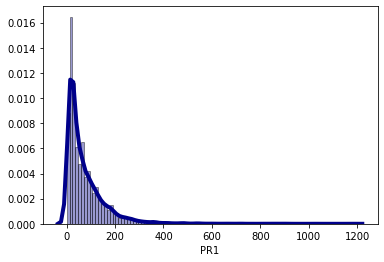

In [8]:
     

sns.distplot(plot_df['PR1'], hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(plot_df['PR1'].describe())



,scaled_PR1
count,1.459500e+04
mean,-8.392662e-17
std,1.000034e+00
min,-9.068853e-01
25%,-6.686420e-01
50%,-3.428392e-01
75%,3.237863e-01
max,1.355876e+01


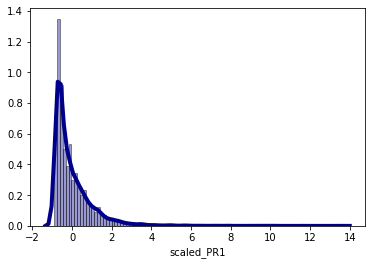

In [11]:
scaler = StandardScaler()

plot_df['scaled_PR1'] = scaler.fit_transform(plot_df[['PR1']])

     

sns.distplot(plot_df['scaled_PR1'], hist=True, kde=True, 
             bins=100, color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

pd.DataFrame(plot_df['scaled_PR1'].describe())



# Notes
- This is going to be inherently bias --> if we identify ppl using HCPF metrics, we can only identify the same people they have already identified. Regardless of whether or not they are truly bad actors

## No functions approach to scoring
- only saving incase we need it again

In [ ]:
# call preprocessing function
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

# fit data from column transformer
transformed_q1 = preprocessor_refine.transformers[0][1].fit_transform(df_q1_2019[binary_features+num_features])

# make data a pandas dataframe
df_refined = pd.DataFrame(defined_preprocessor=preprocessor_refine, data=transformed_q1, columns=features_names, index=df_q1_2019.index)

# add the indicies back to the transformed data
df_intermediate = pd.concat([df_q1_2019[index], df_refined], axis=1)

# set the indicies
df_for_scoring = df_intermediate.set_index(['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date'])
df_for_scoring.head()

In [ ]:
df_q1_final = scoring_sum(df_for_scoring)
df_q1_final.head()

In [ ]:
print(df_q1_final.groupby(['Bin']).size())
q1_bad_actors = df_q1_final.loc[df_q1_final['Risk_Score']>50].reset_index()['PRSCRB_PROV_LOC_ID'].tolist()
print('List of suspected bad actors: ', q1_bad_actors)

In [ ]:
# Plot of how frequently prescribers appear as high risk
bad_actors_sorted = sorted(q1_bad_actors+q2_bad_actors+q3_bad_actors+q4_bad_actors)
sns.countplot(bad_actors_sorted)
plt.title('High Risk Prescribers 2019')
plt.xlabel('Prescriber ID')
plt.ylabel('# of Qs of high risk')
plt.xticks(rotation=45);

### weighting system

In [2]:
df_weights = pd.DataFrame([[1,2,3],[4,5,6],[7,8,9]], columns=['A','B','C'])
df_weights.head()

,A,B,C
0,1,2,3
1,4,5,6
2,7,8,9


In [19]:
weights_dict = {'B':1,'C':20,'A':10,'B':30, 'D':100}

In [ ]:
df_weights*weights_dict

In [ ]:
for col in df_weights:
    pri

In [18]:
df_weights.columns

Index(['A', 'B', 'C'], dtype='object')

In [26]:
df_q1_2019.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,25,55,4270.0,2019-03-26,2019-01-02,114867,84,2.2,170.800000,0.654762,50.833333,0.075342,0.04,2,0.0,0.0,0.024390,0.418182,0.790875,0,0,0.0,0.000000,5,0.7,0.0,0.080000,0.0,0.0,0.000000,0,0.0
1,18,18,175.0,2019-03-25,2019-01-13,102896,72,1.0,9.722222,0.250000,2.430556,0.108108,0.00,0,0.0,0.0,0.000000,0.777778,0.783133,0,0,0.0,0.055556,0,0.0,0.0,0.111111,0.0,0.0,0.333333,0,0.0
2,5,15,710.0,2019-03-25,2019-01-02,104658,83,3.0,142.000000,0.180723,8.554217,0.102041,0.00,1,0.0,0.0,0.018868,0.133333,0.897959,0,0,0.0,0.200000,0,0.0,0.0,0.200000,0.0,0.0,0.000000,0,0.2
3,1,1,28.0,2019-01-11,2019-01-11,122110,1,1.0,28.000000,1.000000,28.000000,0.500000,1.00,0,0.0,0.0,0.000000,0.000000,0.857143,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0
4,5,20,733.0,2019-03-20,2019-01-01,122574,79,4.0,146.600000,0.253165,9.278481,0.034783,0.00,1,0.0,0.0,0.050000,0.150000,0.642857,0,0,0.0,0.200000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0


In [32]:
df_q1_2019[['PR11']].describe()

,PR11
count,13451.000000
mean,0.395505
std,0.379082
min,0.000000
25%,0.000000
50%,0.309524
75%,0.750000
max,1.000000


In [44]:
# dispensed per member
df_q1_2019[['PR1']].describe()

,PR1
count,13451.000000
mean,71.407807
std,84.278709
min,0.500000
25%,17.550000
50%,42.500000
75%,96.000000
max,1780.000000


In [34]:
# Rx per day
df_q1_2019[['PR4']].describe()

,PR4
count,13451.000000
mean,0.455136
std,0.640325
min,0.022472
25%,0.102041
50%,0.200000
75%,0.712644
max,17.089888


In [62]:
df_q1_2019['PR18'].value_counts(dropna=False)

0    13440
1       11
Name: PR18, dtype: int64

In [63]:
len(df_q1_2019[df_q1_2019['PR18'] == 1])

11

In [64]:
n = df_q1_2019.shape[0]
p = len(df_q1_2019[df_q1_2019['PR18'] == 1])/n
q = (1-p)
print(n, p, q)

13451 0.0008177830644561742 0.9991822169355439


In [65]:
q

0.9991822169355439

In [15]:
df_q1_2019.shape

(13451, 32)

In [54]:
stats.binom.stats(n, p)[0]

array(11.)

In [34]:
stats.binom.cdf(r, n, p)

0.9074833863678791

In [33]:
r=15

In [38]:
risky_df = pd.read_csv('/project_data/data_asset/2019q1_riskscore.csv')
risky_df.head()

,PRSCRB_PROV_LOC_ID,Risk_Score
0,122110,4.667035
1,165027,71.037740
2,118005,10.457246
3,25176,5.717627
4,114836,5.714308


In [80]:
!ls '/project_data/data_asset'

2019q1_clusteredrisk.csv
2019q1_riskscore.csv
2019q2_clusteredrisk.csv
2019q2_riskscore.csv
2019q3_clusteredrisk.csv
2019q3_riskscore.csv
2019q4_clusteredrisk.csv
2019q4_riskscore.csv
2020q1_clusteredrisk.csv
2020q1_riskscore.csv
2020q2_clusteredrisk.csv
2020q2_riskscore.csv
arcgis_creds_alex.json
colorado-latest.osm.bz2
connect_oracle_db.R
creds.json
final_op_analysis_01012020_03312020.csv
final_op_analysis_04012019_06302019.csv
final_op_analysis_04012020_06302020.csv
final_op_analysis_07012019_09302019.csv
final_op_analysis_10012019_12312019.csv
joined_df.csv
joined_df_with_clusters.csv
ojdbc6.jar
op_analysis_01012018_03312018.csv
op_analysis_01012019_03312019.csv
op_analysis_01012020_03312020.csv
op_analysis_04012018_06302018.csv
op_analysis_04012019_06302019.csv
op_analysis_07012018_09302018.csv
op_analysis_07012019_09302019.csv
op_analysis_10012018_12312018.csv
op_analysis_10012019_12312019.csv
op_analysis.csv
op_analysis_with_nulls.csv
op_analysis_with_nulls_with_labels.csv
provi

In [41]:
hasbinary_2019 = df_q1_2019.loc[df_q1_2019['PR18']==1]['PRSCRB_PROV_LOC_ID'].tolist()

In [42]:
risky_df.loc[risky_df['PRSCRB_PROV_LOC_ID'].isin(hasbinary_2019)]

,PRSCRB_PROV_LOC_ID,Risk_Score
427,114449,3.115031
3447,108197,25.399351
3591,105160,2.599898
4596,152051,3.317905
6233,8480,2.944096
7555,110605,8.010224
7707,107933,6.064841
8549,17347,9.722716
9825,5561,1.415504
11367,121062,1.894874


In [66]:
df_q1_2019.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,25,55,4270.0,2019-03-26,2019-01-02,114867,84,2.2,170.800000,0.654762,50.833333,0.075342,0.04,2,0.0,0.0,0.024390,0.418182,0.790875,0,0,0.0,0.000000,5,0.7,0.0,0.080000,0.0,0.0,0.000000,0,0.0
1,18,18,175.0,2019-03-25,2019-01-13,102896,72,1.0,9.722222,0.250000,2.430556,0.108108,0.00,0,0.0,0.0,0.000000,0.777778,0.783133,0,0,0.0,0.055556,0,0.0,0.0,0.111111,0.0,0.0,0.333333,0,0.0
2,5,15,710.0,2019-03-25,2019-01-02,104658,83,3.0,142.000000,0.180723,8.554217,0.102041,0.00,1,0.0,0.0,0.018868,0.133333,0.897959,0,0,0.0,0.200000,0,0.0,0.0,0.200000,0.0,0.0,0.000000,0,0.2
3,1,1,28.0,2019-01-11,2019-01-11,122110,1,1.0,28.000000,1.000000,28.000000,0.500000,1.00,0,0.0,0.0,0.000000,0.000000,0.857143,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0
4,5,20,733.0,2019-03-20,2019-01-01,122574,79,4.0,146.600000,0.253165,9.278481,0.034783,0.00,1,0.0,0.0,0.050000,0.150000,0.642857,0,0,0.0,0.200000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.0


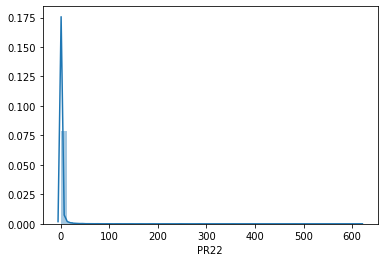

In [67]:
sns.distplot(df_q1_2019['PR22'])

In [68]:
df_q1_2019['PR22'].describe()

count    13451.000000
mean         1.809382
std         11.683322
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        616.000000
Name: PR22, dtype: float64

In [71]:
import math

In [74]:

math.sqrt((.9*.1*100))

3.0000000000000004

In [77]:
df_q2_2019 = pd.read_csv('/project_data/data_asset/revised_op_analysis_04012019_06302019.csv')
df_q2_2019['PR18'].value_counts(dropna=False)

0    13440
1        9
Name: PR18, dtype: int64

In [79]:
df_q1_2019['PR15'].value_counts(dropna=False)

0    13451
Name: PR15, dtype: int64

## test out pandas cut bin edges

In [5]:
x = pd.Series([4,6,1,10,2,5,9,7,8,5,9], dtype=int)

In [19]:
pd.cut(x, [1,5,10], include_lowest=True)

0     (0.999, 5.0]
1      (5.0, 10.0]
2     (0.999, 5.0]
3      (5.0, 10.0]
4     (0.999, 5.0]
5     (0.999, 5.0]
6      (5.0, 10.0]
7      (5.0, 10.0]
8      (5.0, 10.0]
9     (0.999, 5.0]
10     (5.0, 10.0]
dtype: category
Categories (2, interval[float64]): [(0.999, 5.0] < (5.0, 10.0]]

In [20]:
pd.cut(x, 2)

0     (0.991, 5.5]
1      (5.5, 10.0]
2     (0.991, 5.5]
3      (5.5, 10.0]
4     (0.991, 5.5]
5     (0.991, 5.5]
6      (5.5, 10.0]
7      (5.5, 10.0]
8      (5.5, 10.0]
9     (0.991, 5.5]
10     (5.5, 10.0]
dtype: category
Categories (2, interval[float64]): [(0.991, 5.5] < (5.5, 10.0]]